# Section 4 — cumulative Nash regret vs round $t$

**One figure (three panels):** adversaries 1–3. **x-axis:** round $t$ (linear). **y-axis:** $\log_{10}$ (cumulative Nash regret). **Curves:** UCB, EXP3, OurAlg — mean $\pm$ std. **Dashed vertical line** at $T/2$ (phase switch).

Set **`RUN_MODE`** in the code cell: **FAST**, **STANDARD**, or **HEAVY**.

Saved: D:\Users\Mateo\Personal\_Seminar_RL\Zero-Sum-MatrixGames\Bandit_feedback\Nash_regret_curve_section4\plots\section4_cumulative_nashregret_heavy_T50000.png


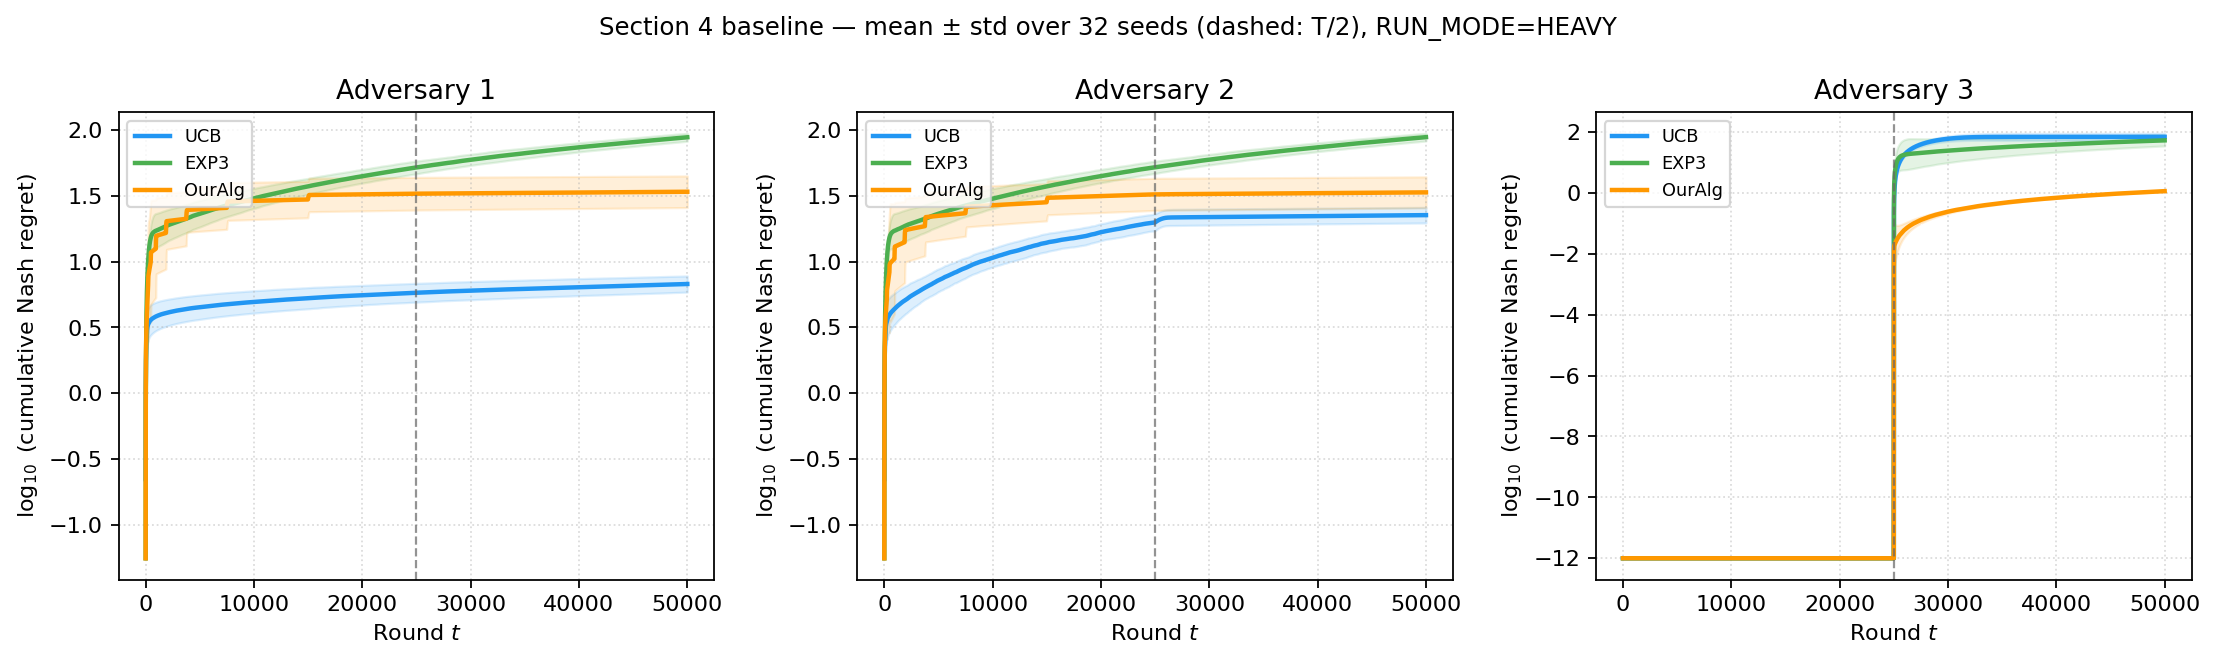

In [1]:
%matplotlib inline

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_here = Path.cwd()
if not (_here / "curves.py").is_file():
    for _cand in (
        _here / "Nash_regret_curve_section4",
        _here / "Bandit_feedback" / "Nash_regret_curve_section4",
    ):
        if (_cand / "curves.py").is_file():
            os.chdir(_cand)
            _here = Path.cwd()
            break
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

from curves import (
    exp3_cumulative_curve,
    mean_std_curves,
    ouralg_cumulative_curve,
    ucb_cumulative_curve,
)
from notebook_plot_backend import show_figure_in_notebook

RUN_MODE = "HEAVY"  # "FAST" | "STANDARD" | "HEAVY"

if RUN_MODE == "FAST":
    T, N_RUNS = 4000, 16
elif RUN_MODE == "STANDARD":
    T, N_RUNS = 10000, 32
elif RUN_MODE == "HEAVY":
    T, N_RUNS = 50000, 32
else:
    raise ValueError(RUN_MODE)

BASE_SEED = 42
palette = {"UCB": "#2196F3", "EXP3": "#4CAF50", "OurAlg": "#FF9800"}
specs = [
    ("UCB", ucb_cumulative_curve),
    ("EXP3", exp3_cumulative_curve),
    ("OurAlg", ouralg_cumulative_curve),
]

t_axis = np.arange(1, T + 1, dtype=float)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=False)

for ax, adv in zip(axes, [1, 2, 3]):
    for label, fn in specs:
        mean_c, std_c = mean_std_curves(fn, T, adv, N_RUNS, base_seed=BASE_SEED)
        y = np.log10(np.maximum(mean_c, 1e-12))
        log_std = std_c / np.maximum(mean_c, 1e-12) / np.log(10.0)
        c = palette[label]
        ax.plot(t_axis, y, label=label, color=c, lw=2)
        ax.fill_between(t_axis, y - log_std, y + log_std, alpha=0.15, color=c)
    ax.axvline(T // 2, color="0.4", ls="--", lw=1, alpha=0.7)
    ax.set_xlabel("Round $t$")
    ax.set_ylabel(r"$\log_{10}$ (cumulative Nash regret)")
    ax.set_title(f"Adversary {adv}")
    ax.grid(True, ls=":", alpha=0.45)
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle(
    f"Section 4 baseline — mean ± std over {N_RUNS} seeds (dashed: T/2), RUN_MODE={RUN_MODE}",
    fontsize=11,
)
plt.tight_layout()

OUT_DIR = _here / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
fp = OUT_DIR / f"section4_cumulative_nashregret_{RUN_MODE.lower()}_T{T}.png"
plt.savefig(fp, dpi=160, bbox_inches="tight")
print("Saved:", fp.resolve())
show_figure_in_notebook(fig, dpi=160)
plt.close(fig)